## Lab 1 (Sydney Golden)

Group number: 2

Group members: Sydney Golden, Porhay Rouen, Cameron Mangione

## Examining Salaries of Data Scientists

Despite having one more year until our program ends, finding a job post graduation is a hot (and anxiety inducing) topic in our cohort. Our proactive team would like to get a head start on the job searching process, therefore will be analyzing the salaries of data scientists in the 2020s.  


## Dataset

Data Sources:

https://www.kaggle.com/datasets/arnabchaki/data-science-salaries-2023
https://www.kaggle.com/datasets/ruchi798/data-science-job-salaries?select=ds_salaries.csv

Our team will be merging two data sets from Kaggle: one with salaries only from the year 2023 and the other with values from the 2020s. Both of the data sets contain the same columns, including variables such as job title, salary in USD, employment type, company size and experience level.

## The following information is directly from the 2023 data set:

Data Science Job Salaries Dataset contains 11 columns, each are:

work_year: The year the salary was paid.

experience_level: The experience level in the job during the yearemployment_type: The type of employment for the role

job_title: The role worked in during the year.

salary: The total gross salary amount paid.

salary_currency: The currency of the salary paid as an ISO 4217 currency code.

salaryinusd: The salary in USD

employee_residence: Employee's primary country of residence in during the work year as an ISO 3166 country code.

remote_ratio: The overall amount of work done remotely

company_location: The country of the employer's main office or contracting branch

company_size: The median number of people that worked for the company during the year

## EDA

Description of the dataset source: Kaggle

Definition of key variables: Job title, salary in USD, employment type, company size and experience level

Data types (numeric, categorical, ordinal, etc.): Numerical and categorical

Handling missing values: No missing values.

Data preprocessing steps: Outer join of both data sets


## Summary statistics: 

In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [107]:
# Please note that the data sets have already been merged
df = pd.read_csv("https://raw.githubusercontent.com/porhay007/GROUP-PROJECT-2-DATA-5322/refs/heads/main/ds_salaries_merged.csv")

In [108]:
print("Dataset Preview:")
print(df.head())

Dataset Preview:
   ID  work_year experience_level employment_type              job_title  \
0   1       2020               EX              FT     Staff Data Analyst   
1   2       2020               MI              FT  Business Data Analyst   
2   3       2020               EN              FT          Data Engineer   
3   4       2020               EN              FT          Data Engineer   
4   5       2020               EN              FT           Data Analyst   

    salary salary_currency  salary_in_usd employee_residence  remote_ratio  \
0    15000             USD          15000                 NG             0   
1    95000             USD          95000                 US             0   
2  1000000             INR          13493                 IN           100   
3  1000000             INR          13493                 IN           100   
4    20000             EUR          22809                 PT           100   

  company_location company_size  
0               CA     

In [109]:
df.describe()

,ID,work_year,salary,salary_in_usd,remote_ratio
count,4362.000000,4362.000000,4.362000e+03,4362.000000,4362.000000
mean,2181.500000,2022.238881,2.092457e+05,134053.558230,49.701972
std,1259.345266,0.768427,8.496508e+05,64797.957697,48.325818
min,1.000000,2020.000000,4.000000e+03,2859.000000,0.000000
25%,1091.250000,2022.000000,9.391825e+04,90000.000000,0.000000
50%,2181.500000,2022.000000,1.350000e+05,130000.000000,50.000000
75%,3271.750000,2023.000000,1.800000e+05,173000.000000,100.000000
max,4362.000000,2023.000000,3.040000e+07,600000.000000,100.000000


In [110]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4362 entries, 0 to 4361
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   ID                  4362 non-null   int64 
 1   work_year           4362 non-null   int64 
 2   experience_level    4362 non-null   object
 3   employment_type     4362 non-null   object
 4   job_title           4362 non-null   object
 5   salary              4362 non-null   int64 
 6   salary_currency     4362 non-null   object
 7   salary_in_usd       4362 non-null   int64 
 8   employee_residence  4362 non-null   object
 9   remote_ratio        4362 non-null   int64 
 10  company_location    4362 non-null   object
 11  company_size        4362 non-null   object
dtypes: int64(5), object(7)
memory usage: 409.1+ KB


## Visualizations (histograms, boxplots, scatterplots, correlation plots): 

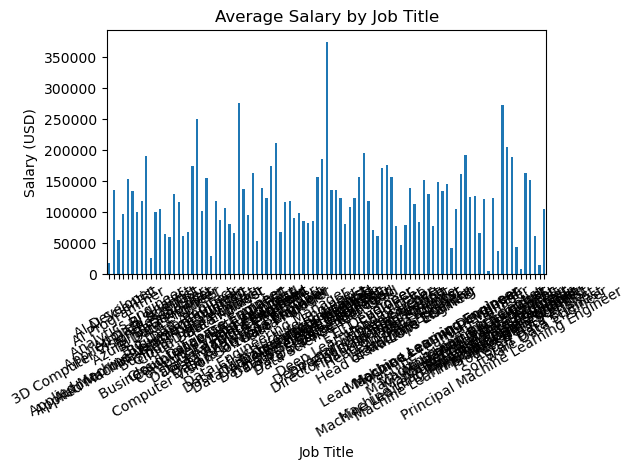

In [111]:
# Plot 1: Average Salary by Job Title

plt.figure()
df.groupby('job_title')['salary_in_usd'].mean().plot(kind='bar')
plt.title('Average Salary by Job Title')
plt.xlabel('Job Title')
plt.ylabel('Salary (USD)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

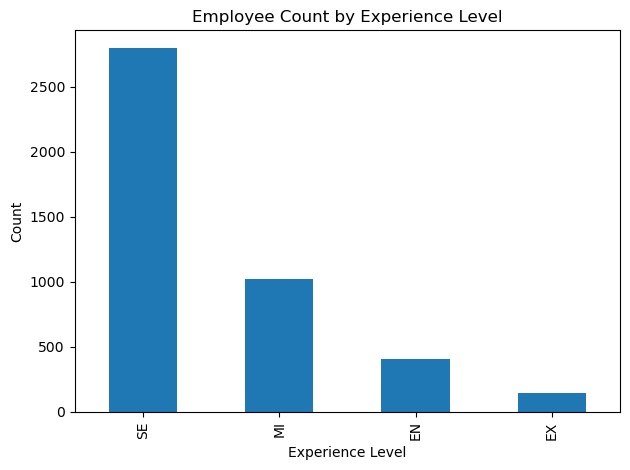

In [112]:
#  Plot 2: Count by Experience Level
plt.figure()
df['experience_level'].value_counts().plot(kind='bar')
plt.title('Employee Count by Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

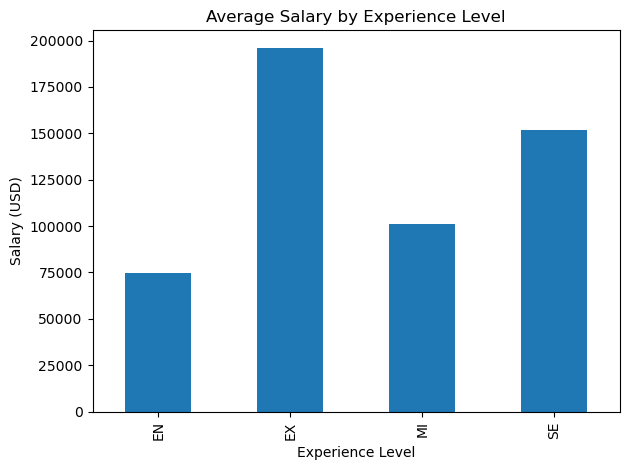

In [113]:
# Plot 3: Salary by Experience Level
plt.figure()
df.groupby('experience_level')['salary_in_usd'].mean().plot(kind='bar')
plt.title('Average Salary by Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('Salary (USD)')
plt.tight_layout()
plt.show()

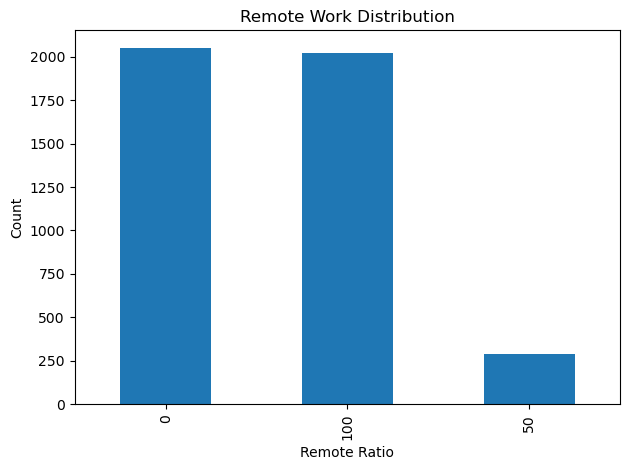

In [114]:
# Plot 4: Remote Ratio Distribution
plt.figure()
df['remote_ratio'].value_counts().plot(kind='bar')
plt.title('Remote Work Distribution')
plt.xlabel('Remote Ratio')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

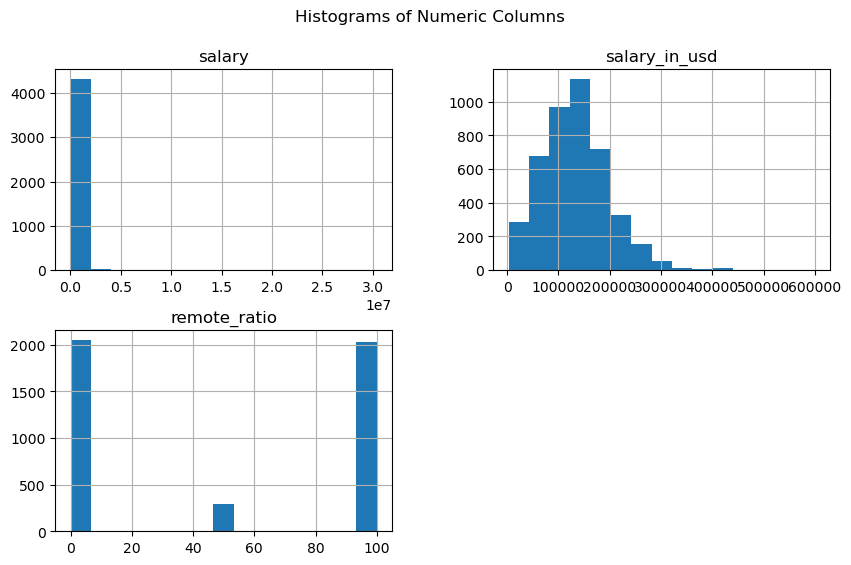

In [115]:
# Histograms
numeric_columns = ['salary', 'salary_in_usd', 'remote_ratio']  # adjust numeric columns as needed
df[numeric_columns].hist(bins=15, figsize=(10,6))
plt.suptitle("Histograms of Numeric Columns")
plt.show()

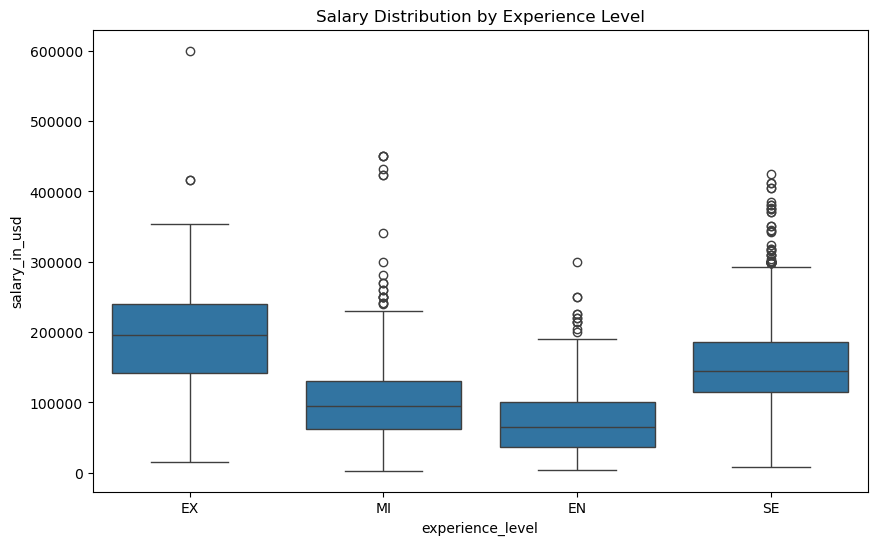

In [116]:
# Boxplots

plt.figure(figsize=(10,6))
sns.boxplot(x='experience_level', y='salary_in_usd', data=df)
plt.title("Salary Distribution by Experience Level")
plt.show()

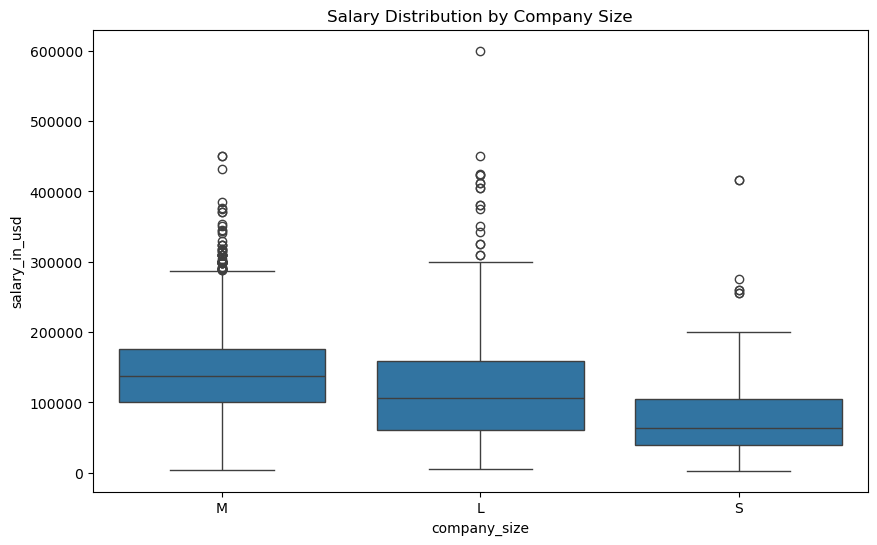

In [117]:
# Boxplot for company size vs salary
plt.figure(figsize=(10,6))
sns.boxplot(x='company_size', y='salary_in_usd', data=df)
plt.title("Salary Distribution by Company Size")
plt.show()

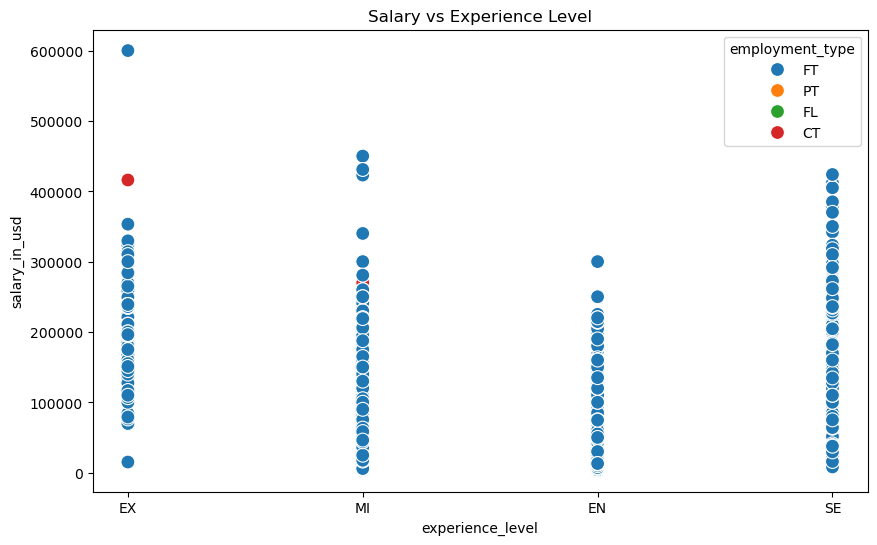

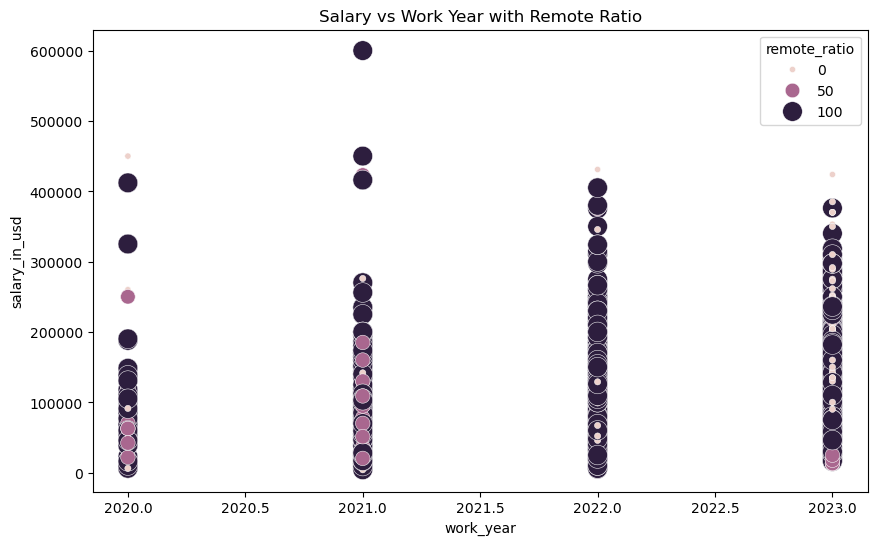

In [118]:
# Scatterplot

plt.figure(figsize=(10,6))
sns.scatterplot(x='experience_level', y='salary_in_usd', hue='employment_type', data=df, s=100)
plt.title("Salary vs Experience Level")
plt.show()

plt.figure(figsize=(10,6))
sns.scatterplot(x='work_year', y='salary_in_usd', hue='remote_ratio', size='remote_ratio', sizes=(20,200), data=df)
plt.title("Salary vs Work Year with Remote Ratio")
plt.show()

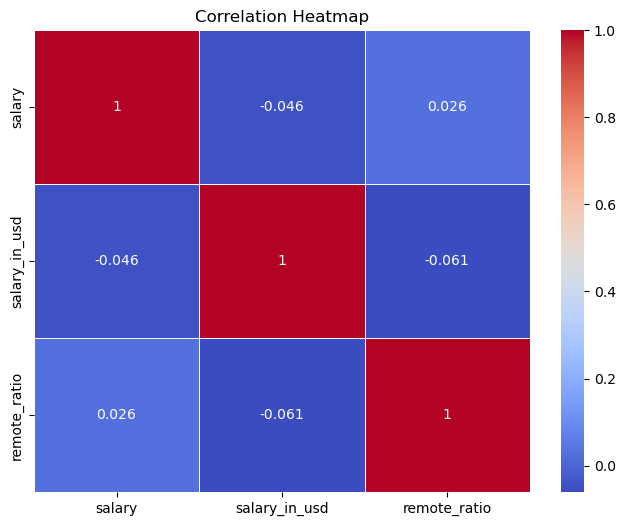

In [119]:
# Correlation Plot (Heatmap)
plt.figure(figsize=(8,6))
correlation_matrix = df[numeric_columns].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

## Identification of potential predictor variables, response variables etc.

Predictor Variables:

work_year

experience_level

employment_type

job_title

employee_residence

remote_rate

company_location

company_size

Response Variables:

salary

salary_in_usd